In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import statsmodels.formula.api as smf
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.linear_model import LassoCV, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression as SklearnLR

# Interaction Model

In [2]:
df = pd.read_csv("processed_f1_dataset.csv")

# Filter for the modern pit stop era and handle real-world outliers
# We exclude pre-2011 data (where pit times are 0) and filter out extreme outliers 
# (e.g., total pit times over 200 seconds, which usually indicate crash repairs or red flags).
df = df[(df['year'] >= 2011) & 
              (df['total_pit_time_sec'] > 0) & 
              (df['total_pit_time_sec'] < 200)].copy()

# Filter out DNFs for stronger correlation
df = df[df['statusId'] == 1]

# To model the interaction between overtaking difficulty and pit stop importance
# We need to develop a map for overtaking difficulty for each circuit/race
# We develop this by defining: position_change = abs(grid−positionOrder), avg position changes
df['position_change'] = abs(df['grid'] - df['positionOrder'])
#Define the difficulty for overtaking for each circuity by this avg
circuit_overtaking = (df.groupby('circuitRef')['position_change']
    .mean()
    .reset_index())

# Normalize and reverse order so we get: HIGH values = harder overtaking
scaler = MinMaxScaler()
circuit_overtaking['overtake_ease'] = scaler.fit_transform(
    circuit_overtaking[['position_change']])

circuit_overtaking['overtake_diff'] = (1 - circuit_overtaking['overtake_ease'])

# Merge back
df = df.merge(
    circuit_overtaking[['circuitRef', 'overtake_diff']],
    on='circuitRef',
    how='left')

# Interaction Model Definition
model = smf.ols(
    formula='positionOrder ~ total_pit_time_sec * overtake_diff',
    data=df).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          positionOrder   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     24.11
Date:                Sun, 31 May 2026   Prob (F-statistic):           2.11e-15
Time:                        01:01:48   Log-Likelihood:                -7812.8
No. Observations:                2779   AIC:                         1.563e+04
Df Residuals:                    2775   BIC:                         1.566e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

<Figure size 1000x600 with 0 Axes>

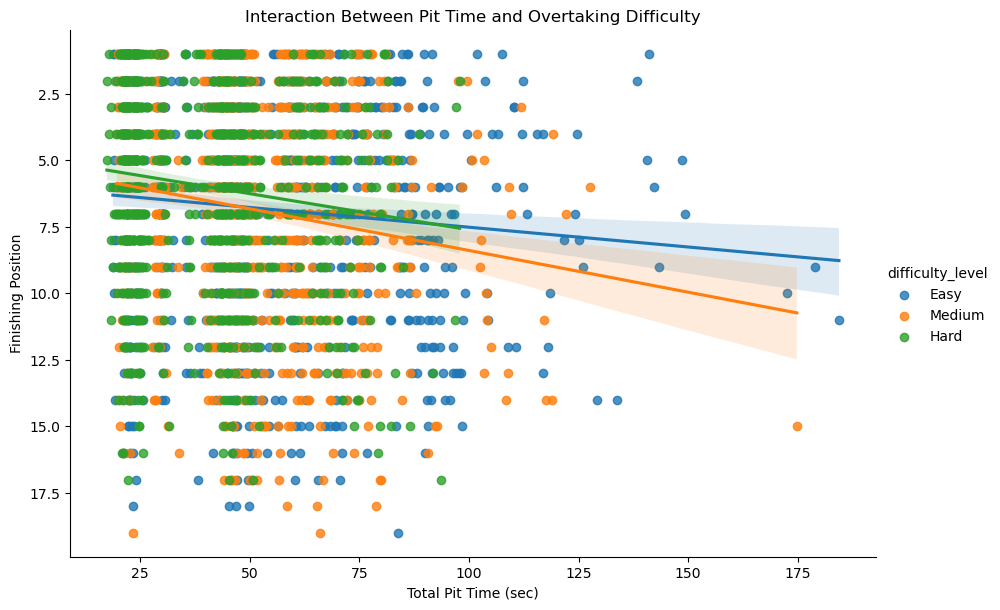

In [3]:
# Categorize circuit overtaking difficulty for easier visualization
df['difficulty_level'] = pd.qcut(
    df['overtake_diff'],
    q=3,
    labels=['Easy', 'Medium', 'Hard']
)

plt.figure(figsize=(10,6))

sns.lmplot(
    data=df,
    x='total_pit_time_sec',
    y='positionOrder',
    hue='difficulty_level',
    aspect=1.5,
    height=6
)

plt.title('Interaction Between Pit Time and Overtaking Difficulty')
plt.xlabel('Total Pit Time (sec)')
plt.ylabel('Finishing Position')
plt.gca().invert_yaxis()  #better finishes higher visually
plt.show()

These results suggest that pit stop time significantly depends on overtaking difficulty. We can conclude that longer pit times result in worse finishing positions, this correlation supports our first hypothesis. However, we should still control for potentially confounding variables like different racers, manufacturers, and starting positions:

# Interaction Model Controls

In [4]:
# Formula for controls C creates numeric vals for categorical variables
# Note that for almost all observations, driverIDs and contstructorIDs are highly correlated
# which should be obvious considering drivers drive usually for a single brand, so we only include driverID

# We should also mean center our interaction model to reduce insignificant correlations not important
# to our confounds: 
df['pit_centered'] = (
    df['total_pit_time_sec']
    - df['total_pit_time_sec'].mean())

df['diff_centered'] = (
    df['overtake_diff']
    - df['overtake_diff'].mean())

model = smf.ols(
    formula='positionOrder ~ pit_centered * diff_centered + grid + C(driverId)',
    data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          positionOrder   R-squared:                       0.608
Model:                            OLS   Adj. R-squared:                  0.598
Method:                 Least Squares   F-statistic:                     60.06
Date:                Sun, 31 May 2026   Prob (F-statistic):               0.00
Time:                        01:01:49   Log-Likelihood:                -6546.4
No. Observations:                2779   AIC:                         1.323e+04
Df Residuals:                    2708   BIC:                         1.366e+04
Df Model:                          70                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

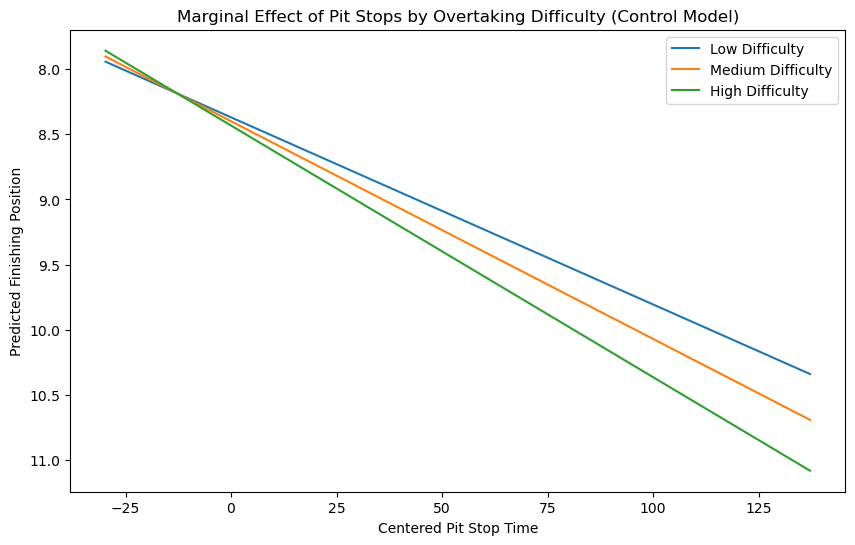

In [5]:
# For visualizations we are going to split model predictions based on overtaking difficulty
# We need to see how the model performs predictively

# Define difficulty by percentile to avg across drivers and grid
diff_low = df['diff_centered'].quantile(0.25)
diff_mid = df['diff_centered'].quantile(0.50)
diff_high = df['diff_centered'].quantile(0.75)

mean_grid = df['grid'].mean()

# Range of centered pit times to evaluate predictions over
pit_range = np.linspace(df['pit_centered'].min(), df['pit_centered'].max(), 100)

# all drivers
drivers = df['driverId'].unique()

def marginal_curve(pit_vals, diff_value):
    preds = []
    for d in drivers:
        temp = pd.DataFrame({
            'pit_centered': pit_vals,
            'diff_centered': diff_value,
            'grid': mean_grid,
            'driverId': d})

        preds.append(model.predict(temp))
    avg = np.mean(preds, axis=0)

    return pd.DataFrame({
        'pit_centered': pit_vals,
        'pred': avg
    })
low_curve = marginal_curve(pit_range, diff_low)
mid_curve = marginal_curve(pit_range, diff_mid)
high_curve = marginal_curve(pit_range, diff_high)

plt.figure(figsize=(10,6))

plt.plot(low_curve['pit_centered'], low_curve['pred'], label='Low Difficulty')
plt.plot(mid_curve['pit_centered'], mid_curve['pred'], label='Medium Difficulty')
plt.plot(high_curve['pit_centered'], high_curve['pred'], label='High Difficulty')

plt.xlabel('Centered Pit Stop Time')
plt.ylabel('Predicted Finishing Position')
plt.title('Marginal Effect of Pit Stops by Overtaking Difficulty (Control Model)')
plt.gca().invert_yaxis()
plt.legend()
plt.show()

The controlled interaction model shows that the marginal effect of pit stop time on finishing position increases with overtaking difficulty, indicating that time lost in the pit lane is more costly on circuits where position recovery is harder. While the interaction effect is statistically significant, its magnitude is modest relative to stronger predictors such as starting grid position and driver-specific effects. This is reflected in the fact that most of the explained variance in finishing position is driven by these structural factors rather than pit stop performance alone (small R^2). 

# Ridge Regression

Best lambda: 53.366992312063125
Coefficients:
[ 0.13744084 -0.16242049  0.24813184  2.7357479 ]
Test MSE: 8.823533841765848


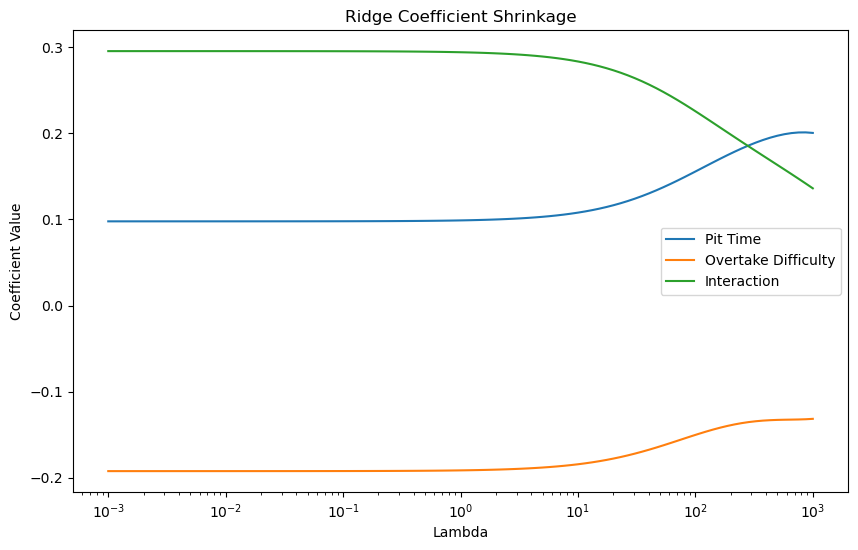

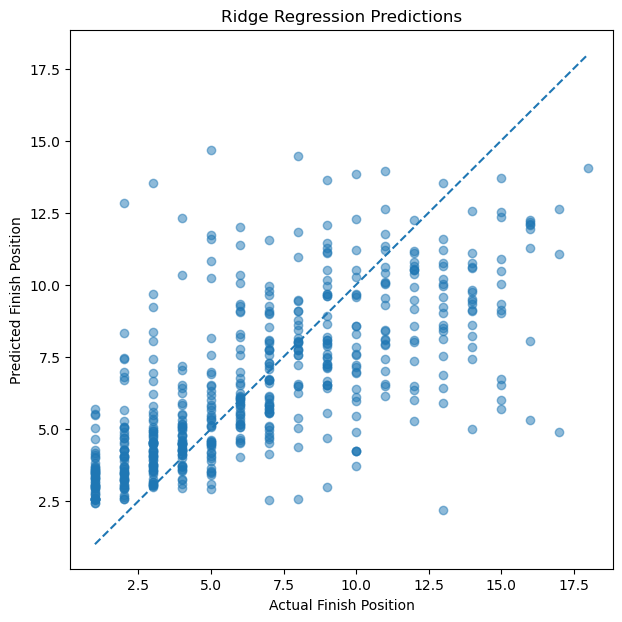


Ridge 5 fold CV MSE: 8.4302


In [6]:
df_ridge = df[['total_pit_time_sec', 'overtake_diff', 'grid', 'positionOrder']].dropna().copy()
df_ridge['interaction'] = (df_ridge['total_pit_time_sec'] * df_ridge['overtake_diff'])

X = df_ridge[['total_pit_time_sec', 'overtake_diff', 'interaction', 'grid']]
y = df_ridge['positionOrder']

X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.2,
    random_state=42)

# Standardize Features for Ridge
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

alphas = np.logspace(-3, 3, 100)

# RidgeCV: 5 fold cross validation
# Each fold uses ~80% of data for training and ~20% for validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
ridge_cv = RidgeCV(alphas = alphas, cv=kf, scoring = 'neg_mean_squared_error')
ridge_cv.fit(X_train_scaled, y_train)

best_lambda = ridge_cv.alpha_

print("Best lambda:", best_lambda)

ridge_model = Ridge(alpha=best_lambda)
ridge_model.fit(X_train_scaled, y_train)
print("Coefficients:")
print(ridge_model.coef_)

y_pred = ridge_model.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test, y_pred)
print("Test MSE:", ridge_mse)

coefs = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    coefs.append(ridge.coef_)

coefs = np.array(coefs)

# Plot coefficient reduction for lambda range 
# lets us see interaction coeffs contribution
plt.figure(figsize=(10,6))
plt.plot(alphas, coefs[:,0], label='Pit Time')
plt.plot(alphas, coefs[:,1], label='Overtake Difficulty')
plt.plot(alphas, coefs[:,2], label='Interaction')
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('Coefficient Value')
plt.title('Ridge Coefficient Shrinkage')
plt.legend()
plt.show()

# Plot true and predicted finishing position based on interaction/coeffs 
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--')
plt.xlabel('Actual Finish Position')
plt.ylabel('Predicted Finish Position')
plt.title('Ridge Regression Predictions')
plt.show()

# CV MSE for Ridge using the best lambda for model comparison
ridge_cv_mse = -cross_val_score(
    Ridge(alpha=best_lambda),
    X_scaled,
    y,
    cv=kf,
    scoring='neg_mean_squared_error'
).mean()
print(f"\nRidge 5 fold CV MSE: {ridge_cv_mse:.4f}")

Ridge Regression applies L2 penalty to the regression coeffs, the application of the L2 penalty to our interaction model (no controls) using pit stop time, overtaking difficulty, and their interaction as predictors of finishing position shows: Five-fold cross-validation selected an optimal regularization parameter of λ = 53.37. The resulting model achieved a test MSE of 8.82. Regression shows that predictions are concentrated near the mean finishing position and nearly follow the true labels, indicating some predictive accuracy. The coefficient shrinkage plot demonstrates that increasing regularization reduces all coefficient magnitudes toward zero while retaining all predictors. The interaction term remains relatively influential under regularization, suggesting that the effect of pit stop time may depend on circuit overtaking difficulty, although the overall explanatory power of the model remains modest.

# Lasso Regression

Lasso (Least Absolute Shrinkage and Selection Operator) applies L1 penalty to the regression coefficients, shrinking lesser important predictors to zero. This performs automatic feature selection, helping us identify which variables contribute to the finishing position. We use 5 fold cross validation for the regularization parameter α (lambda).

Best alpha (lambda) selected by CV: 0.0016


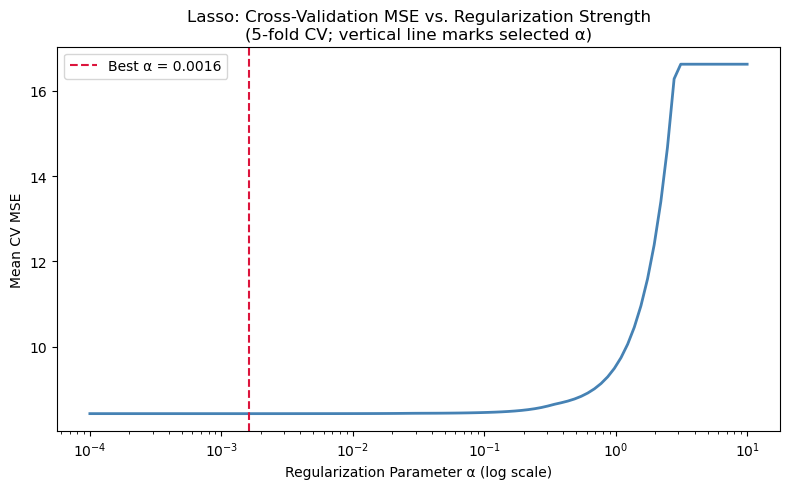

In [7]:
# Build feature matrix for Lasso: same predictors as interaction model
lasso_df = df[['total_pit_time_sec', 'overtake_diff', 'grid', 'positionOrder']].dropna().copy()
lasso_df['pit_x_diff'] = lasso_df['total_pit_time_sec'] * lasso_df['overtake_diff']

feature_cols = ['total_pit_time_sec', 'overtake_diff', 'pit_x_diff', 'grid']
X = lasso_df[feature_cols].values
y = lasso_df['positionOrder'].values

# Standardize features
scaler_lasso = StandardScaler()
X_scaled = scaler_lasso.fit_transform(X)

# LassoCV: 5 fold cross validation
# Each fold uses ~80% of data for training and ~20% for validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lasso_cv = LassoCV(alphas=np.logspace(-4, 1, 100), cv=kf, max_iter=10000)
lasso_cv.fit(X_scaled, y)

best_alpha = lasso_cv.alpha_
print(f"Best alpha (lambda) selected by CV: {best_alpha:.4f}")

# Plot mean CV MSE
mean_mse = np.mean(lasso_cv.mse_path_, axis=1)

plt.figure(figsize=(8, 5))
plt.semilogx(lasso_cv.alphas_, mean_mse, color='steelblue', linewidth=2)
plt.axvline(best_alpha, color='crimson', linestyle='--', label=f'Best α = {best_alpha:.4f}')
plt.xlabel('Regularization Parameter α (log scale)')
plt.ylabel('Mean CV MSE')
plt.title('Lasso: Cross-Validation MSE vs. Regularization Strength\n'
          '(5-fold CV; vertical line marks selected α)')
plt.legend()
plt.tight_layout()
plt.show()

Lasso Coefficients (standardized):
           Feature  Coefficient
total_pit_time_sec     0.066202
     overtake_diff    -0.209873
        pit_x_diff     0.330398
              grid     2.814164


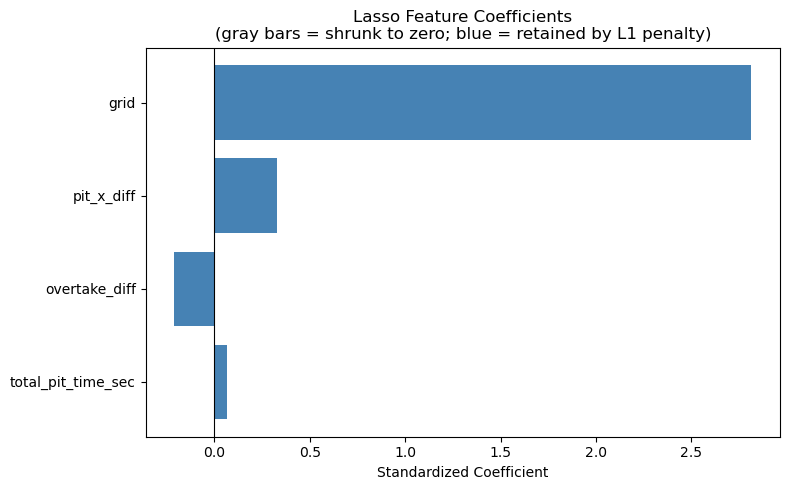


Lasso 5 fold CV MSE: 8.4262


In [8]:
# Fit final Lasso model on full dataset using the best alpha
lasso_final = Lasso(alpha=best_alpha, max_iter=10000)
lasso_final.fit(X_scaled, y)

# Show which features survived the L1 penalty (non-zero coefficients)
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lasso_final.coef_
})
print("Lasso Coefficients (standardized):")
print(coef_df.to_string(index=False))

# Coefficient bar chart — zero bars indicate features Lasso eliminated
colors = ['steelblue' if c != 0 else 'lightgray' for c in coef_df['Coefficient']]

plt.figure(figsize=(8, 5))
bars = plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Standardized Coefficient')
plt.title('Lasso Feature Coefficients\n'
          '(gray bars = shrunk to zero; blue = retained by L1 penalty)')
plt.tight_layout()
plt.show()

# CV MSE for Lasso using the best alpha for model comparison later
lasso_cv_mse = -cross_val_score(
    Lasso(alpha=best_alpha, max_iter=10000),
    X_scaled, y,
    cv=kf,
    scoring='neg_mean_squared_error'
).mean()
print(f"\nLasso 5 fold CV MSE: {lasso_cv_mse:.4f}")

The bar chart above shows which predictors survived the L1 penalty. Features shrunk to zero were not important enough to survive the penalty. This tells us that Lasso is performing feature selection and retained features with their relative magnitudes indicatinng their importance to predicting finishing position after regularization

# KNN Regression

K-Nearest Neighbors (KNN) is a non-parametric model that predicts finishing position by averaging the outcomes of the K most similar observations in the training set. It does not make any assumptions about the linearity and is a flexible benchmark to compare against the parametric regression models. We select K using 5 fold cross validation over a range of K=1 to K=50

Best K: 31  |  CV MSE at best K: 8.3885


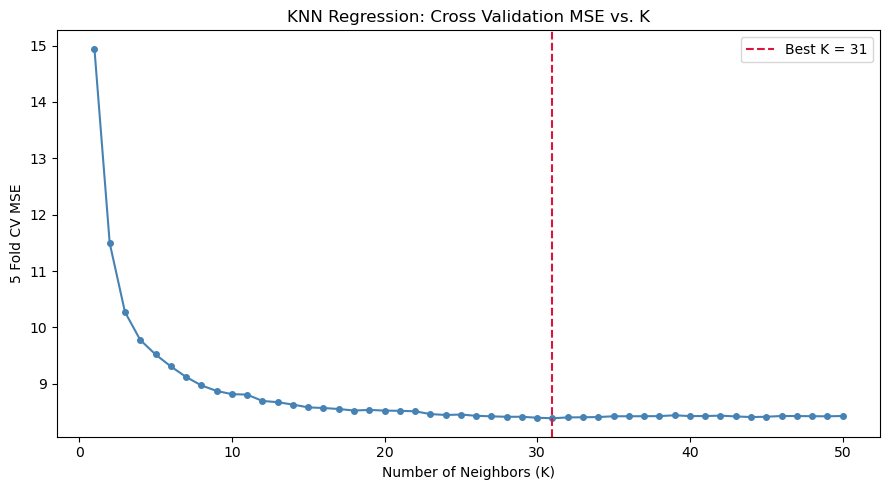

In [9]:
k_values = range(1, 51)
cv_mse_per_k = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=kf, scoring='neg_mean_squared_error')
    cv_mse_per_k.append(-scores.mean())

best_k = k_values[np.argmin(cv_mse_per_k)]
best_knn_mse = min(cv_mse_per_k)
print(f"Best K: {best_k}  |  CV MSE at best K: {best_knn_mse:.4f}")

# Plot CV MSE vs K, shows the bias-variance tradeoff:
# small K = high variance, large K = high bias
plt.figure(figsize=(9, 5))
plt.plot(list(k_values), cv_mse_per_k, marker='o', markersize=4,
         color='steelblue', linewidth=1.5)
plt.axvline(best_k, color='crimson', linestyle='--', label=f'Best K = {best_k}')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('5 Fold CV MSE')
plt.title('KNN Regression: Cross Validation MSE vs. K')
plt.legend()
plt.tight_layout()
plt.show()

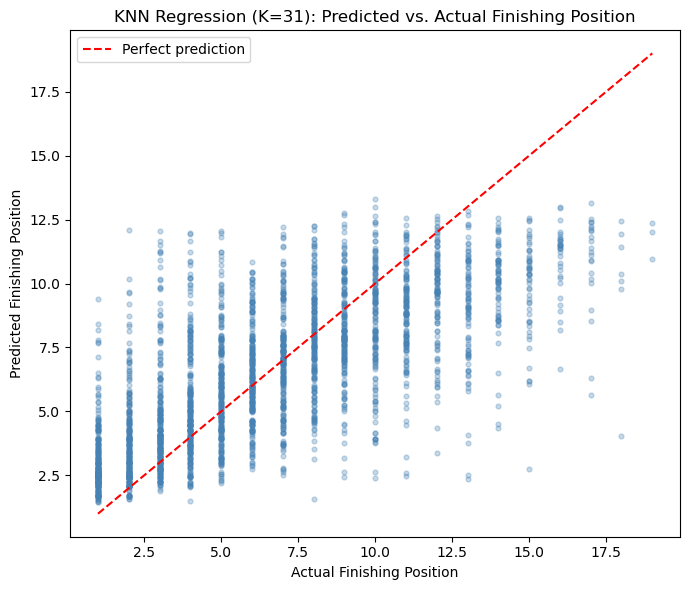

KNN Training MSE (K=31): 7.8017
KNN 5-fold CV MSE (K=31): 8.3885


In [10]:
# Fit final KNN on the full dataset using the best K
knn_final = KNeighborsRegressor(n_neighbors=best_k)
knn_final.fit(X_scaled, y)
y_pred_knn = knn_final.predict(X_scaled)

# Predicted vs Actual scatter plot points near the diagonal indicate accurate predictions
plt.figure(figsize=(7, 6))
plt.scatter(y, y_pred_knn, alpha=0.3, s=12, color='steelblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Finishing Position')
plt.ylabel('Predicted Finishing Position')
plt.title(f'KNN Regression (K={best_k}): Predicted vs. Actual Finishing Position')
plt.legend()
plt.tight_layout()
plt.show()

train_mse_knn = mean_squared_error(y, y_pred_knn)
print(f"KNN Training MSE (K={best_k}): {train_mse_knn:.4f}")
print(f"KNN 5-fold CV MSE (K={best_k}): {best_knn_mse:.4f}")

# Model Comparison

We compare all models using 5 fold cross validated MSE

                       Model  5-Fold CV MSE
                  KNN (K=31)         8.3885
            Lasso Regression         8.4262
Linear Regression (baseline)         8.4266
            Ridge Regression         8.4302


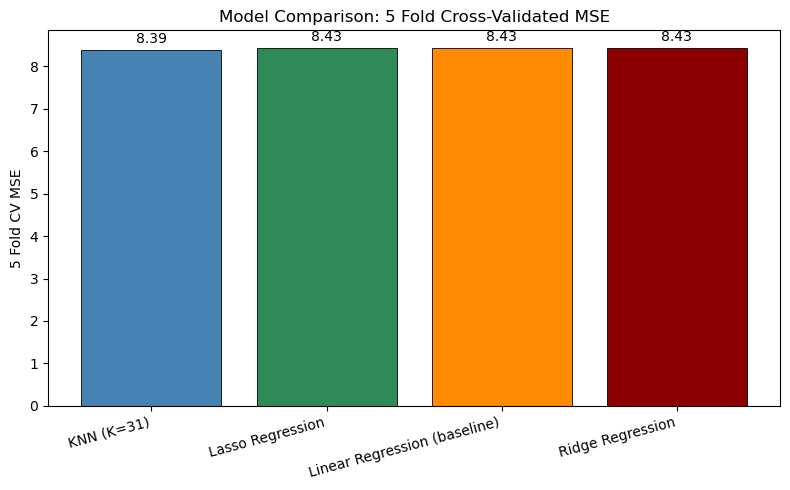

In [11]:
# Compute CV MSE for the baseline interaction model using the same 4 feature matrix so the comparison is fair
baseline_lr = SklearnLR()
baseline_cv_mse = -cross_val_score(
    baseline_lr, X_scaled, y, cv=kf, scoring='neg_mean_squared_error'
).mean()

# Collect results into a summary table
comparison = pd.DataFrame({
    'Model': ['Linear Regression (baseline)', 'Ridge Regression', 'Lasso Regression', f'KNN (K={best_k})'],
    '5-Fold CV MSE': [round(baseline_cv_mse, 4),
                      round(ridge_cv_mse, 4),
                      round(lasso_cv_mse, 4),
                      round(best_knn_mse, 4)]
})
comparison = comparison.sort_values('5-Fold CV MSE').reset_index(drop=True)
print(comparison.to_string(index=False))

# Bar chart of CV MSE across models
palette = ['steelblue', 'seagreen', 'darkorange', 'darkred']
plt.figure(figsize=(8, 5))
bars = plt.bar(comparison['Model'], comparison['5-Fold CV MSE'],
               color=palette[:len(comparison)], edgecolor='black', linewidth=0.6)
plt.ylabel('5 Fold CV MSE')
plt.title('Model Comparison: 5 Fold Cross-Validated MSE')
plt.xticks(rotation=15, ha='right')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.1,
             f'{bar.get_height():.2f}',
             ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

The model comparison shows that all four models achieve similar 5 fold CV MSE on four features. Lasso's performance closely aligns with linear regression and exactly matches ridge regression, indicating that the L1 penalty did not need to zero out features and the L2 penalty produced nearly identical predictive performance through coefficient shrinkage rather than variable elimination: this suggests that all four predictors carry some importance. KNN's CV MSE reflects its flexibility, but without driver-level information, no model in this comparison captures more than a fraction of the variance in finishing position. This is consistent with the low R² observed in the baseline interaction model. The dominant predictors remain starting grid position and driver skill, which sit outside the pit stop focused feature set used in this research.